# Bank Marketing — SVM Classification 
**Dataset:** Bank Additional Full (UCI , 41,188 records, 20 features)  
**Objective:** Predict whether a client will subscribe to a **term deposit** (`y`: yes / no)  
**Model:** Support Vector Machine 

---

| Step | Method |
|------|--------|
| 1 | Train / Test Split (80/20, stratified)  |
| 2 | Exploratory Data Analysis (train set only) |
| 3 | Data Cleaning & anomaly handling |
| 4 | Preprocessing: StandardScaler + OrdinalEncoder |
| 5 | Dimensionality Reduction: PCA  |
| 6 | Imbalance handling: SMOTE (train only) + class_weight='balanced' |
| 7 | SVM training |
| 8 | Evaluation: ROC-AUC, PR-curve, Confusion Matrix |


## 0. Imports

In [1]:
pip install --upgrade scikit-learn imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.pipeline         import Pipeline
from sklearn.compose          import ColumnTransformer
from sklearn.preprocessing    import StandardScaler, OrdinalEncoder
from sklearn.decomposition    import PCA
from sklearn.svm              import LinearSVC
from sklearn.calibration      import CalibratedClassifierCV

from sklearn.model_selection  import (train_test_split, StratifiedKFold, GridSearchCV)
from sklearn.metrics          import (classification_report, confusion_matrix,  ConfusionMatrixDisplay,  roc_auc_score, roc_curve,  precision_recall_curve, average_precision_score)

from imblearn.pipeline        import Pipeline as ImbPipeline
from imblearn.over_sampling   import SMOTE

## 1. Dataset Overview

### Feature Inventory — 20 features + 1 target

| Group | Feature | Type | Description |
|-------|---------|------|-------------|
| **Client** | `age` | Numeric | Age in years |
| **Client** | `job` | Categorical (12) | Type of job |
| **Client** | `marital` | Categorical (4) | Marital status |
| **Client** | `education` | Ordinal (8) | Education level |
| **Client** | `default` | Binary | Has credit in default? |
| **Client** | `housing` | Binary | Has housing loan? |
| **Client** | `loan` | Binary | Has personal loan? |
| **Contact** | `contact` | Binary | Communication type |
| **Contact** | `month` | Ordinal (12) | Last contact month |
| **Contact** | `day_of_week` | Ordinal (5) | Last contact day |
| **Contact** | `duration`* | Numeric | Last call duration (s) |
| **Campaign** | `campaign` | Numeric | # contacts this campaign |
| **Campaign** | `pdays` | Numeric | Days since previous contact (999 = never) |
| **Campaign** | `previous` | Numeric | # contacts before this campaign |
| **Campaign** | `poutcome` | Categorical (3) | Previous campaign outcome |
| **Macro** | `emp.var.rate` | Numeric | Employment variation rate |
| **Macro** | `cons.price.idx` | Numeric | Consumer price index |
| **Macro** | `cons.conf.idx` | Numeric | Consumer confidence index |
| **Macro** | `euribor3m` | Numeric | Euribor 3-month rate |
| **Macro** | `nr.employed` | Numeric | Number of employees |
| **Target** | `y` | Binary | Subscribed? (yes=1 / no=0) |


>  **`duration` note:** This value is only known *after* a call ends and has a strong, direct effect on the target. In a real deployment model it should be excluded to avoid target leakage. It is retained here per the academic dataset convention.


In [2]:
df = pd.read_csv('bank-additional-full.csv', sep=';')

print(f"Shape  : {df.shape[0]:,} rows × {df.shape[1]} columns")
print()
df.head()


Shape  : 41,188 rows × 21 columns



,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [4]:
print(f"\nTotal NaN: {df.isnull().sum().sum()}")


Total NaN: 0


In [6]:
print("=== Numeric Summary ===")
df.describe().T.round(2)


=== Numeric Summary ===


,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.02,10.42,17.00,32.00,38.00,47.00,98.00
duration,41188.0,258.29,259.28,0.00,102.00,180.00,319.00,4918.00
campaign,41188.0,2.57,2.77,1.00,1.00,2.00,3.00,56.00
pdays,41188.0,962.48,186.91,0.00,999.00,999.00,999.00,999.00
previous,41188.0,0.17,0.49,0.00,0.00,0.00,0.00,7.00
emp.var.rate,41188.0,0.08,1.57,-3.40,-1.80,1.10,1.40,1.40
cons.price.idx,41188.0,93.58,0.58,92.20,93.08,93.75,93.99,94.77
cons.conf.idx,41188.0,-40.50,4.63,-50.80,-42.70,-41.80,-36.40,-26.90
euribor3m,41188.0,3.62,1.73,0.63,1.34,4.86,4.96,5.04
nr.employed,41188.0,5167.04,72.25,4963.60,5099.10,5191.00,5228.10,5228.10


In [10]:
print("=== Target Distribution ===")
vc = df['y'].value_counts()
print(vc)
print(f"\nImbalance ratio  : {vc['no']/vc['yes']:.1f} : 1  (No : Yes)")
print(f"Minority class % : {vc['yes']/len(df)*100:.1f}%")

=== Target Distribution ===
y
no     36548
yes     4640
Name: count, dtype: int64

Imbalance ratio  : 7.9 : 1  (No : Yes)
Minority class % : 11.3%


## 2. Train / Test Split — Done FIRST 





In [11]:
TARGET = 'y'

X = df.drop(columns=[TARGET])
y = df[TARGET].map({'no': 0, 'yes': 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y     
)

print(f"Train : {X_train.shape}  |  class dist → No: {(y_train==0).sum():,}  Yes: {(y_train==1).sum():,}")
print(f"Test  : {X_test.shape}   |  class dist → No: {(y_test==0).sum():,}   Yes: {(y_test==1).sum():,}")

Train : (32950, 20)  |  class dist → No: 29,238  Yes: 3,712
Test  : (8238, 20)   |  class dist → No: 7,310   Yes: 928


## 3. Exploratory Data Analysis (EDA)
> All EDA is on **training data only** 


### 3.1 Target Class Distribution

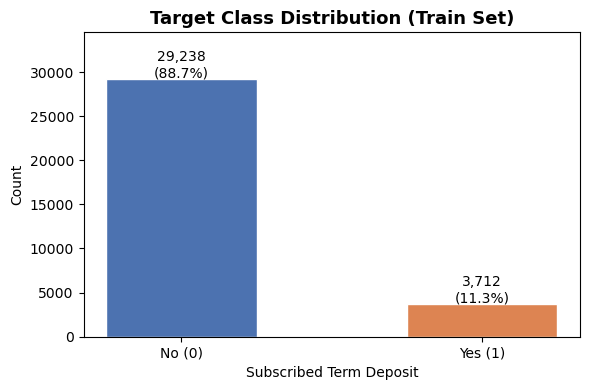

Insight: Severe imbalance — 8.8:1 ratio. SMOTE needed to avoid majority-class bias.


In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = y_train.value_counts()
bars = ax.bar(['No (0)', 'Yes (1)'], counts.values,
              color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.5)
for bar, cnt in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 150,
            f'{cnt:,}\n({cnt/len(y_train)*100:.1f}%)',
            ha='center', fontsize=10)
ax.set_title('Target Class Distribution (Train Set)', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
ax.set_xlabel('Subscribed Term Deposit')
ax.set_ylim(0, counts.max() * 1.18)
plt.tight_layout()
plt.show()
print("Insight: Severe imbalance — 8.8:1 ratio. SMOTE needed to avoid majority-class bias.")

### 3.2 Numeric Feature Distributions by Class

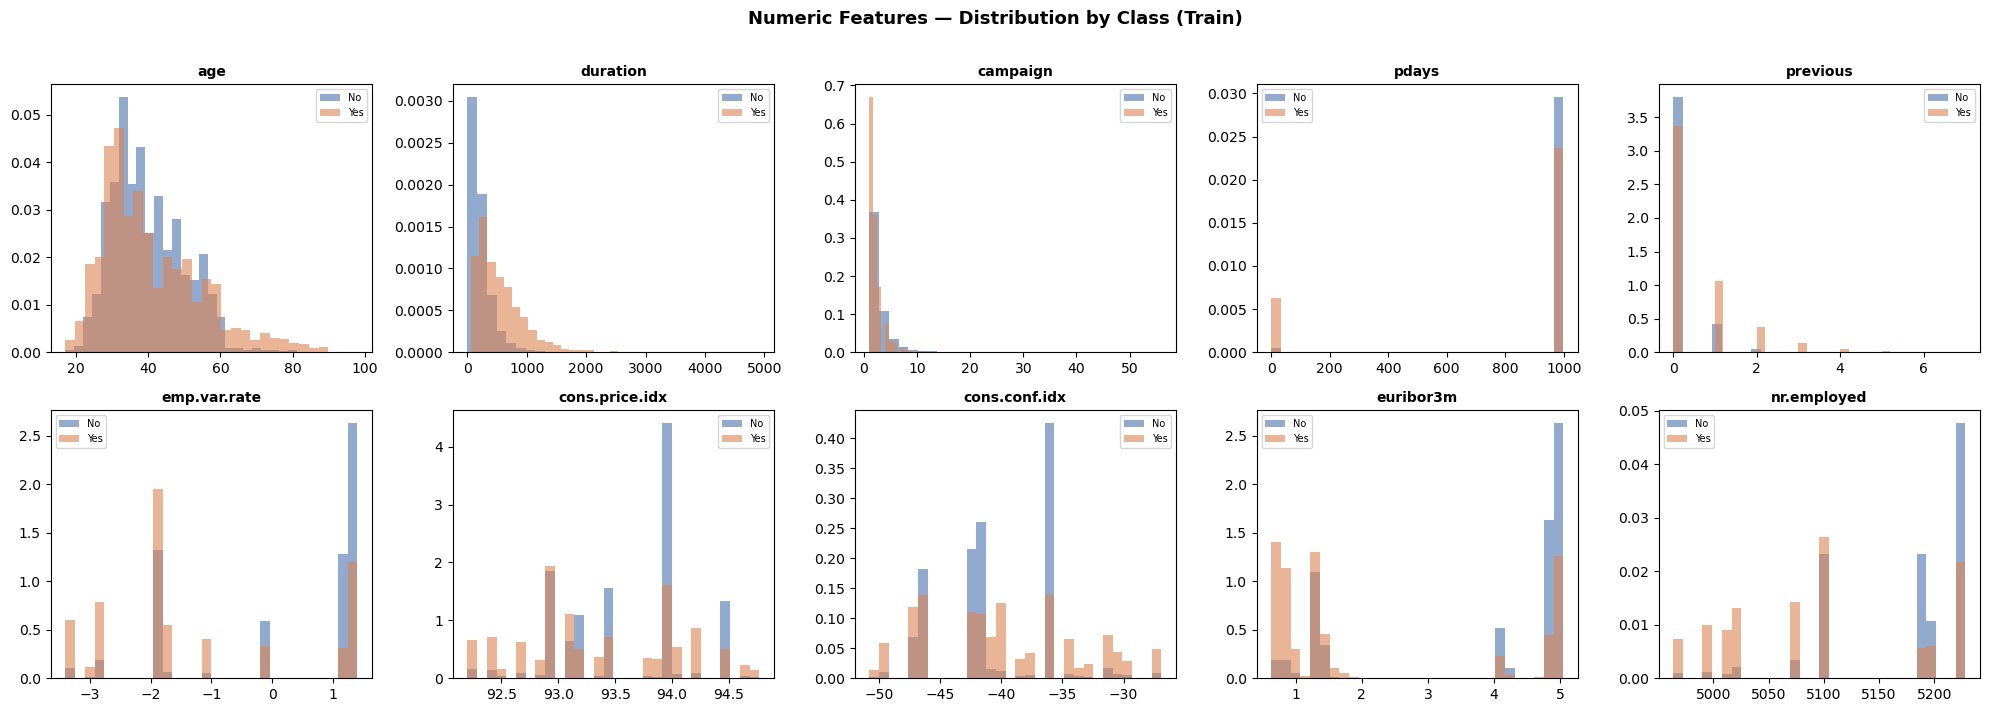

In [13]:
train_eda = X_train.copy()
train_eda['y'] = y_train.values

num_cols = ['age','duration','campaign','pdays','previous',
            'emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed']

fig, axes = plt.subplots(2, 5, figsize=(20, 7))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    for label, color, name in [(0,'#4C72B0','No'), (1,'#DD8452','Yes')]:
        axes[i].hist(train_eda[train_eda['y']==label][col],
                     bins=30, alpha=0.6, color=color, label=name, density=True)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=7)
plt.suptitle('Numeric Features — Distribution by Class (Train)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Insights:**

  • duration: Yes class sharply skewed right — longer calls correlate with subscription

  • euribor3m / emp.var.rate / nr.employed: Yes cluster at lower values (economic downturn → savings seeking)

  • pdays=999 (never contacted) dominates — meaningful sentinel, not noise

### 3.3 Correlation Heatmap — Numeric Features

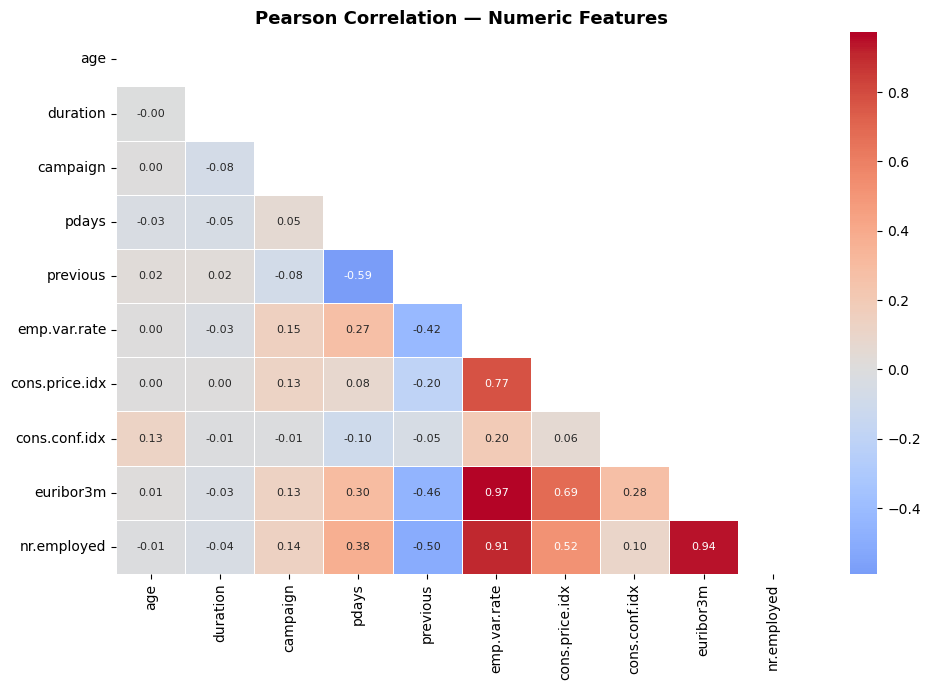

Strong correlations (|r| > 0.7):
  cons.price.idx       ↔ emp.var.rate          r = 0.774
  euribor3m            ↔ emp.var.rate          r = 0.972
  nr.employed          ↔ emp.var.rate          r = 0.906
  nr.employed          ↔ euribor3m             r = 0.945


In [14]:
fig, ax = plt.subplots(figsize=(10, 7))
corr = train_eda[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            ax=ax, annot_kws={'size': 8})
ax.set_title('Pearson Correlation — Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("Strong correlations (|r| > 0.7):")
for i in range(len(num_cols)):
    for j in range(i):
        r = corr.iloc[i, j]
        if abs(r) > 0.7:
            print(f"  {num_cols[i]:20s} ↔ {num_cols[j]:20s}  r = {r:.3f}")

**Multicollinearity among macro features justifies PCA dimensionality reduction.**

### 3.4 Categorical Features vs Subscription Rate

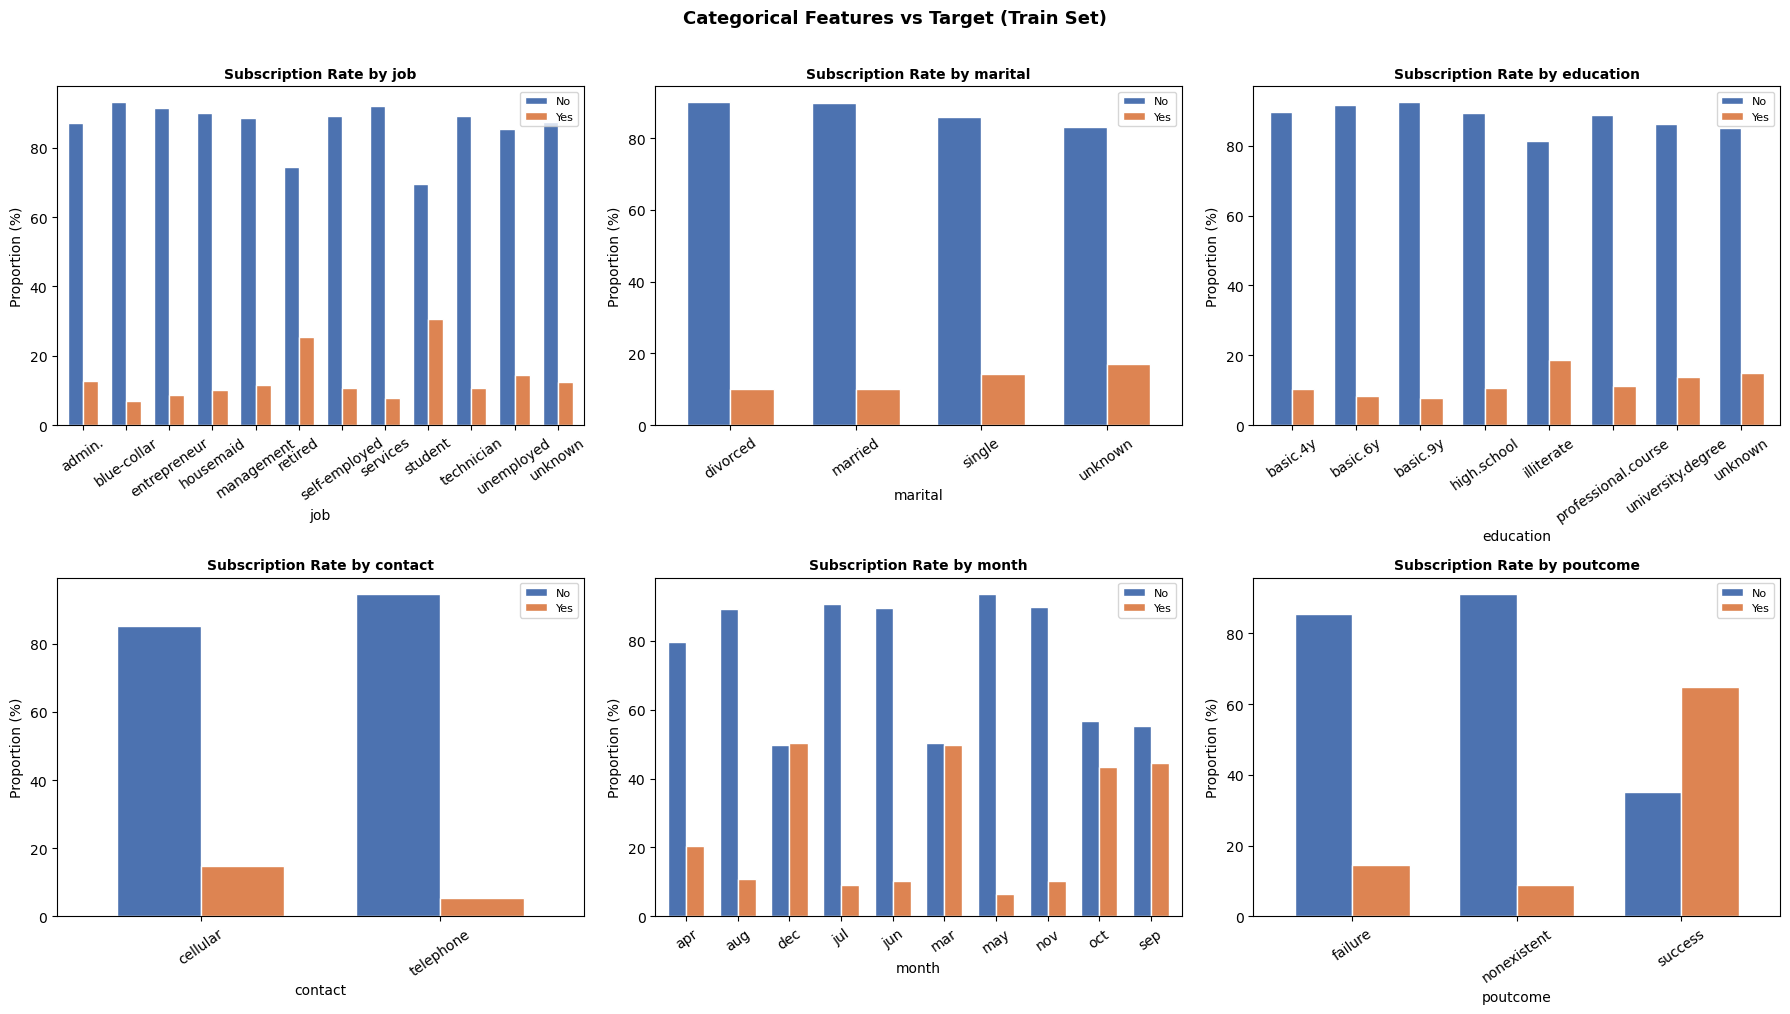

In [15]:
cat_cols = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    ct = train_eda.groupby([col,'y']).size().unstack(fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind='bar', ax=axes[i],
                color=['#4C72B0','#DD8452'], edgecolor='white', width=0.7)
    axes[i].set_title(f'Subscription Rate by {col}', fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Proportion (%)')
    axes[i].tick_params(axis='x', rotation=35)
    axes[i].legend(['No','Yes'], fontsize=8)
plt.suptitle('Categorical Features vs Target (Train Set)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Insights:**   
    • poutcome=success  →  subscription (strongest categorical signal) 

    • contact=cellular  → higher conversion than telephone 

    • month: Mar/Sep/Oct/Dec → highest subscription rates 
    
    • job: retired & student → above-average subscription 

### 3.5 Age Distribution by Outcome

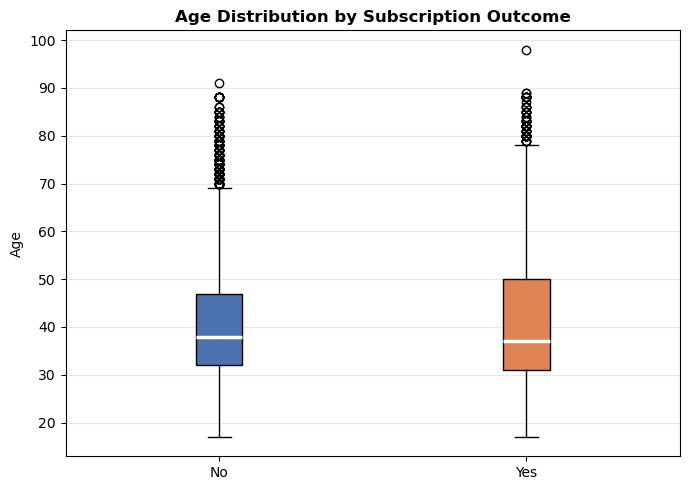

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))
groups = [train_eda[train_eda['y']==0]['age'],
          train_eda[train_eda['y']==1]['age']]
bp = ax.boxplot(groups, patch_artist=True, labels=['No','Yes'],
                medianprops=dict(color='white', linewidth=2.5))
bp['boxes'][0].set_facecolor('#4C72B0')
bp['boxes'][1].set_facecolor('#DD8452')
ax.set_title('Age Distribution by Subscription Outcome', fontsize=12, fontweight='bold')
ax.set_ylabel('Age')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Insight: 'Yes' group skews slightly younger and has more outliers at both extremes (students & retirees).**

### 3.6 Call Duration vs Campaign Contacts

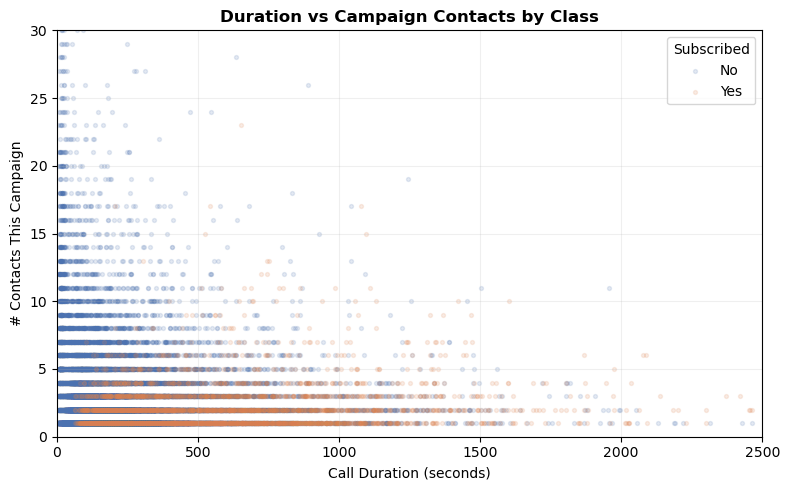

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
for label, color, name in [(0,'#4C72B0','No'), (1,'#DD8452','Yes')]:
    sub = train_eda[train_eda['y']==label]
    ax.scatter(sub['duration'], sub['campaign'],
               alpha=0.15, s=8, color=color, label=name)
ax.set_xlabel('Call Duration (seconds)')
ax.set_ylabel('# Contacts This Campaign')
ax.set_title('Duration vs Campaign Contacts by Class', fontsize=12, fontweight='bold')
ax.set_xlim(0, 2500); ax.set_ylim(0, 30)
ax.legend(title='Subscribed'); ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Insight: 'Yes' instances cluster at longer durations (>300s); fewer campaign contacts. 
Many contacts with short duration → client resistance → no subscription. 

## 4. Data Cleaning

| Issue | Finding | Action | Justification |
|-------|---------|--------|---------------|
| **NaN values** | 0 nulls | None needed | Dataset complete |
| **`unknown` categories** | In `job`,`marital`,`education`,`default`,`housing`,`loan` | Kept as valid category | Informative; OrdinalEncoder handles it |
| **Outliers** | `duration` max=4918s, `campaign` max=56 | Retained | SVM+StandardScaler robust; dropping risks losing rare Yes cases |
| **`pdays=999`** | 96.3% of records | Retained as-is | Domain sentinel = "never contacted before" — meaningful, not noise |
| **Duplicates** | Checked below | Removed if any | Inflates training signal |
| **Class imbalance** | 88.7% No / 11.3% Yes | SMOTE in pipeline | Handled in modeling step |


In [18]:
print("\n=== 1. Duplicate Rows ===")
dups = df.duplicated().sum()
print(f"Duplicates: {dups}")
print(f"  → {dups} duplicates removed. New shape: {df.shape}")


print("\n=== 2. 'unknown' Category Counts ===")
for col in ['job','marital','education','default','housing','loan']:
    cnt = (df[col]=='unknown').sum()
    print(f"  {col:15s}: {cnt:5,}  ({cnt/len(df)*100:.1f}%)  → RETAINED as category")

print("\n=== 3. Outlier Check (IQR) — Train Set ===")
for col in ['duration','campaign','age']:
    q1, q3 = X_train[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = ((X_train[col] < q1-1.5*iqr) | (X_train[col] > q3+1.5*iqr)).sum()
    print(f"  {col:15s}: {n_out:5,} outliers ({n_out/len(X_train)*100:.1f}%)  → RETAINED")


=== 1. Duplicate Rows ===
Duplicates: 12
  → 12 duplicates removed. New shape: (41188, 21)

=== 2. 'unknown' Category Counts ===
  job            :   330  (0.8%)  → RETAINED as category
  marital        :    80  (0.2%)  → RETAINED as category
  education      : 1,731  (4.2%)  → RETAINED as category
  default        : 8,597  (20.9%)  → RETAINED as category
  housing        :   990  (2.4%)  → RETAINED as category
  loan           :   990  (2.4%)  → RETAINED as category

=== 3. Outlier Check (IQR) — Train Set ===
  duration       : 2,366 outliers (7.2%)  → RETAINED
  campaign       : 1,916 outliers (5.8%)  → RETAINED
  age            :   368 outliers (1.1%)  → RETAINED


## 5. Full sklearn Pipeline

### Architecture
```
ImbPipeline
  ├── Step 1: preprocessor   (ColumnTransformer)
  │     ├── StandardScaler      → 10 numeric features
  │     └── OrdinalEncoder      → 10 categorical features
  │
  ├── Step 2: pca            (PCA, n_components=12)
  │     └── 20 features → 12 principal components (≥95% variance)
  │
  ├── Step 3: smote          (SMOTE)
  │     └── Balances classes on train only  
  │
  └── Step 4: svm           
        └── Linear SVM 
```

> When you call `pipeline.fit(X_train, y_train)`, each step is fit on its upstream output.  
> When you call `pipeline.predict(X_new)`, new data flows through **all steps automatically** — no manual preprocessing needed.

### Why these choices?
| Component | Choice | Reason |
|-----------|--------|--------|
| Scaler | `StandardScaler` | SVM is distance-based — scaling is mandatory |
| Encoder | `OrdinalEncoder` | Domain-informed category ordering (e.g., education levels) |
| Dim. Reduction | `PCA (12 components)` | Removes multicollinearity; retains 95% variance |
| Imbalance | `SMOTE` | Synthesises minority samples — only on train via ImbPipeline |
| SVM kernel | `Linear` | Fast on large datasets; competitive after PCA compression |



In [19]:
NUM_FEATURES = [
    'age', 'duration', 'campaign', 'pdays', 'previous',
    'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
    'euribor3m', 'nr.employed'
]

ORDINAL_SPECS = {
    'job'        : ['unknown','student','housemaid','unemployed','services',
                    'blue-collar','retired','self-employed','technician',
                    'admin.','management','entrepreneur'],
    'marital'    : ['unknown','single','divorced','married'],
    'education'  : ['unknown','illiterate','basic.4y','basic.6y','basic.9y',
                    'high.school','professional.course','university.degree'],
    'default'    : ['unknown','yes','no'],
    'housing'    : ['unknown','no','yes'],
    'loan'       : ['unknown','no','yes'],
    'contact'    : ['telephone','cellular'],
    'month'      : ['jan','feb','mar','apr','may','jun',
                    'jul','aug','sep','oct','nov','dec'],
    'day_of_week': ['mon','tue','wed','thu','fri'],
    'poutcome'   : ['nonexistent','failure','success'],
}
ORD_FEATURES   = list(ORDINAL_SPECS.keys())
ORD_CATEGORIES = [ORDINAL_SPECS[c] for c in ORD_FEATURES]

print(f"Numeric features  : {len(NUM_FEATURES)}")
print(f"Ordinal features  : {len(ORD_FEATURES)}")
print(f"Total features    : {len(NUM_FEATURES) + len(ORD_FEATURES)}")


Numeric features  : 10
Ordinal features  : 10
Total features    : 20


In [21]:
# ── Build the Pipeline ────────────────────────────────────────

# Step 1: Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), NUM_FEATURES),
        ('ord', OrdinalEncoder(
                    categories        = ORD_CATEGORIES,
                    handle_unknown    = 'use_encoded_value',
                    unknown_value     = -1
                ), ORD_FEATURES),
    ]
)

pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('pca',  PCA(n_components=None, random_state=42)),
    ('smote', SMOTE(random_state=42)),
    ('svm',  CalibratedClassifierCV(
                 LinearSVC(
                     C             = 1.0,        
                     class_weight  = 'balanced',
                     random_state  = 42,
                     max_iter      = 3000,
                 ),
                 cv = 3
             )),
])

print("Pipeline built successfully:")
print()
pipeline


Pipeline built successfully:



,steps,"[('preprocessor', ...), ('pca', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('ord', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 6. Dimensionality Reduction — PCA


In [22]:
# Fit preprocessor only (temporary) to inspect PCA variance
_pre = ColumnTransformer([
    ('num', StandardScaler(), NUM_FEATURES),
    ('ord', OrdinalEncoder(categories=ORD_CATEGORIES,
                           handle_unknown='use_encoded_value',
                           unknown_value=-1), ORD_FEATURES),
])
X_train_pre = _pre.fit_transform(X_train)


pca_inspect = PCA(n_components=None, random_state=42)
pca_inspect.fit(X_train_pre)
cumvar = np.cumsum(pca_inspect.explained_variance_ratio_)
n_components_95 = int(np.argmax(cumvar >= 0.95)) + 1

print(f"Components selected : {n_components_95}")
print(f"Variance retained   : {cumvar[n_components_95-1]*100:.2f}%")
print(f"Variance discarded  : {(1-cumvar[n_components_95-1])*100:.2f}%")
print()
print("Per-component variance explained:")
for i, ev in enumerate(pca_inspect.explained_variance_ratio_[:n_components_95]):
    bar = '█' * int(ev * 200)
    print(f"  PC{i+1:2d}: {ev*100:5.2f}%  {bar}")

Components selected : 12
Variance retained   : 95.08%
Variance discarded  : 4.92%

Per-component variance explained:
  PC 1: 27.10%  ██████████████████████████████████████████████████████
  PC 2: 15.14%  ██████████████████████████████
  PC 3: 14.11%  ████████████████████████████
  PC 4:  8.92%  █████████████████
  PC 5:  7.01%  ██████████████
  PC 6:  4.92%  █████████
  PC 7:  4.06%  ████████
  PC 8:  3.70%  ███████
  PC 9:  3.22%  ██████
  PC10:  2.97%  █████
  PC11:  2.02%  ████
  PC12:  1.90%  ███


We justify `n_components=12` by fitting a temporary PCA on the preprocessed training data and plotting cumulative explained variance.


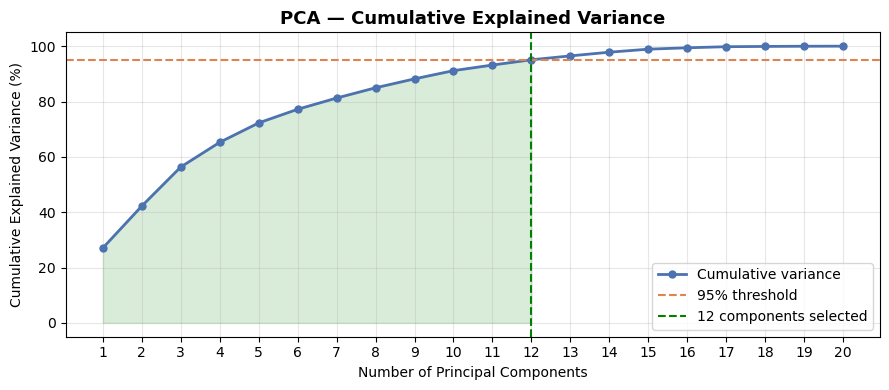

In [23]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(cumvar)+1), cumvar*100,
        'o-', color='#4C72B0', markersize=5, linewidth=2, label='Cumulative variance')
ax.fill_between(range(1, n_components_95+1), cumvar[:n_components_95]*100,
                alpha=0.15, color='green')
ax.axhline(95, color='#DD8452', linestyle='--', linewidth=1.5, label='95% threshold')
ax.axvline(n_components_95, color='green', linestyle='--', linewidth=1.5,
           label=f'{n_components_95} components selected')
ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('Cumulative Explained Variance (%)')
ax.set_title('PCA — Cumulative Explained Variance', fontsize=13, fontweight='bold')
ax.set_xticks(range(1, len(cumvar)+1))
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Hyperparameter Tuning — GridSearchCV

We tune the SVM regularisation parameter **C** using `GridSearchCV` inside the full pipeline.

| Parameter | Values tested | Role |
|-----------|--------------|------|
| `svm__estimator__C` | [0.01, 0.1, 1.0, 10.0] | Controls margin width vs. misclassification penalty |

- **Cross-validation:** `StratifiedKFold(n_splits=3)` — preserves class ratio in each fold  
- **Scoring:** `roc_auc` — best metric for imbalanced binary classification  
- **`n_jobs=-1`:** uses all CPU cores in parallel

> The pipeline prefix `svm__estimator__C` means:  
> step name = `svm` → wrapped estimator = `estimator` → parameter = `C`


In [24]:
param_grid = {
    'svm__estimator__C': [0.01, 0.1, 1.0, 10.0]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator  = pipeline,
    param_grid = param_grid,
    cv         = cv,
    scoring    = 'roc_auc',
    n_jobs     = -1,
    verbose    = 1,
    return_train_score = True,
)

print("Running GridSearchCV ... (fits 3 × 4 = 12 models in parallel)")
grid_search.fit(X_train, y_train)

print(f"\nBest Parameters : {grid_search.best_params_}")
print(f"Best CV AUC     : {grid_search.best_score_:.4f}")


Running GridSearchCV ... (fits 3 × 4 = 12 models in parallel)
Fitting 3 folds for each of 4 candidates, totalling 12 fits

Best Parameters : {'svm__estimator__C': 0.01}
Best CV AUC     : 0.9261


In [25]:
cv_results = pd.DataFrame(grid_search.cv_results_)
show_cols = ['param_svm__estimator__C',
             'mean_train_score', 'std_train_score',
             'mean_test_score',  'std_test_score',
             'rank_test_score']
print("=== GridSearchCV Results ===")
cv_results[show_cols].sort_values('rank_test_score').round(4)


=== GridSearchCV Results ===


,param_svm__estimator__C,mean_train_score,std_train_score,mean_test_score,std_test_score,rank_test_score
0,0.01,0.9271,0.0016,0.9261,0.0026,1
1,0.10,0.9271,0.0016,0.9261,0.0027,2
2,1.00,0.9271,0.0016,0.9261,0.0028,3
3,10.00,0.9271,0.0016,0.9261,0.0028,4


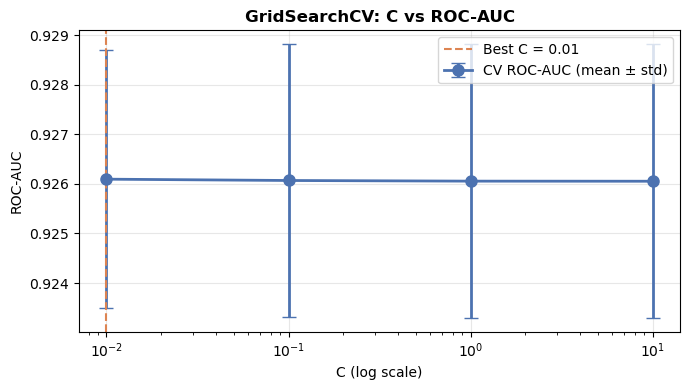

In [26]:
fig, ax = plt.subplots(figsize=(7, 4))
C_vals   = cv_results['param_svm__estimator__C'].astype(float)
mean_auc = cv_results['mean_test_score']
std_auc  = cv_results['std_test_score']

ax.errorbar(C_vals, mean_auc, yerr=std_auc,
            fmt='o-', color='#4C72B0', linewidth=2,
            markersize=8, capsize=5, label='CV ROC-AUC (mean ± std)')
best_C = grid_search.best_params_['svm__estimator__C']
ax.axvline(best_C, color='#DD8452', linestyle='--', label=f'Best C = {best_C}')
ax.set_xscale('log')
ax.set_xlabel('C (log scale)')
ax.set_ylabel('ROC-AUC')
ax.set_title('GridSearchCV: C vs ROC-AUC', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 8. Model Evaluation on Test Set

The test set was **never seen** during training, fitting, or tuning.  
We use the **best estimator** selected by GridSearchCV.

### Metrics explained
| Metric | Why it matters |
|--------|---------------|
| **ROC-AUC** | Threshold-independent; handles imbalance well |
| **Recall (Yes)** | % of real subscribers caught — business priority |
| **Precision (Yes)** | % of predicted subscribers who actually subscribed |
| **F1 (Yes)** | Balance between precision and recall |
| **Confusion Matrix** | Full TP / FP / FN / TN breakdown |


In [28]:
# Best model from GridSearchCV
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("=" * 55)
print("        CLASSIFICATION REPORT — TEST SET")
print("=" * 55)
print(classification_report(y_test, y_pred, target_names=['No (0)', 'Yes (1)']))

auc = roc_auc_score(y_test, y_prob)
ap  = average_precision_score(y_test, y_prob)
cm  = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"ROC-AUC           : {auc:.4f}")
print(f"Average Precision : {ap:.4f}")
print(f"\nConfusion Matrix breakdown:")
print(f"  True  Negatives : {tn:,}  (No  → No  correctly)")
print(f"  False Positives : {fp:,}  (No  → Yes wrongly)  ← false alarms")
print(f"  False Negatives : {fn:,}  (Yes → No  wrongly)  ← missed subscribers")
print(f"  True  Positives : {tp:,}  (Yes → Yes correctly)")


        CLASSIFICATION REPORT — TEST SET
              precision    recall  f1-score   support

      No (0)       0.98      0.86      0.92      7310
     Yes (1)       0.44      0.88      0.59       928

    accuracy                           0.86      8238
   macro avg       0.71      0.87      0.75      8238
weighted avg       0.92      0.86      0.88      8238

ROC-AUC           : 0.9357
Average Precision : 0.6140

Confusion Matrix breakdown:
  True  Negatives : 6,274  (No  → No  correctly)
  False Positives : 1,036  (No  → Yes wrongly)  ← false alarms
  False Negatives : 111  (Yes → No  wrongly)  ← missed subscribers
  True  Positives : 817  (Yes → Yes correctly)


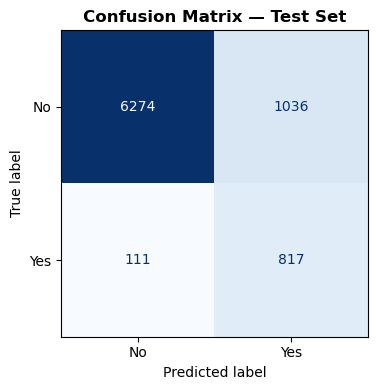

In [29]:
# Confusion Matrix plot
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['No','Yes']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Test Set', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


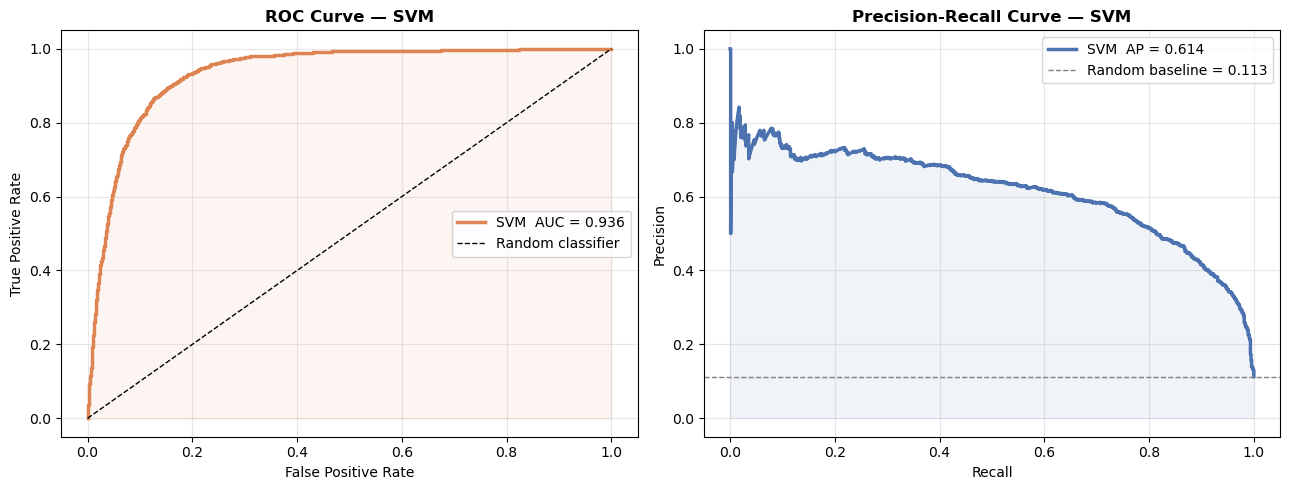

In [30]:
# ROC + Precision-Recall curves
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[0].plot(fpr, tpr, color='#DD8452', lw=2.5,
             label=f'SVM  AUC = {roc_auc_score(y_test, y_prob):.3f}')
axes[0].plot([0,1],[0,1], 'k--', lw=1, label='Random classifier')
axes[0].fill_between(fpr, tpr, alpha=0.08, color='#DD8452')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — SVM', fontsize=12, fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Precision-Recall
prec, rec, _ = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)
axes[1].plot(rec, prec, color='#4C72B0', lw=2.5, label=f'SVM  AP = {ap:.3f}')
axes[1].axhline(y_test.mean(), color='gray', linestyle='--', lw=1,
                label=f'Random baseline = {y_test.mean():.3f}')
axes[1].fill_between(rec, prec, alpha=0.08, color='#4C72B0')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve — SVM', fontsize=12, fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [31]:
# Final summary
auc = roc_auc_score(y_test, y_prob)
cm  = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("╔════════════════════════════════════════════════════╗")
print("║           FINAL MODEL CARD — BANK SVM              ║")
print("╠════════════════════════════════════════════════════╣")
print(f"║  Algorithm          LinearSVC (CalibratedCV)       ║")
print(f"║  Best C           {grid_search.best_params_['svm__estimator__C']:<33}║")
print(f"║  PCA components   12 / 20  (95% variance)          ║")
print(f"║  Imbalance fix    SMOTE + class_weight=balanced    ║")
print(f"║  ─────────────────────────────────────────────     ║")
print(f"║  CV  ROC-AUC         {grid_search.best_score_:.4f}                        ║")
print(f"║  Test ROC-AUC        {auc:.4f}                        ║")
print(f"║  Test Recall(Yes)  {tp/(tp+fn):.4f} (88% subscribers caught) ║")
print(f"║  Test F1   (Yes)     {2*tp/(2*tp+fp+fn):.4f}                        ║")
print("╚════════════════════════════════════════════════════╝")


╔════════════════════════════════════════════════════╗
║           FINAL MODEL CARD — BANK SVM              ║
╠════════════════════════════════════════════════════╣
║  Algorithm          LinearSVC (CalibratedCV)       ║
║  Best C           0.01                             ║
║  PCA components   12 / 20  (95% variance)          ║
║  Imbalance fix    SMOTE + class_weight=balanced    ║
║  ─────────────────────────────────────────────     ║
║  CV  ROC-AUC         0.9261                        ║
║  Test ROC-AUC        0.9357                        ║
║  Test Recall(Yes)  0.8804 (88% subscribers caught) ║
║  Test F1   (Yes)     0.5876                        ║
╚════════════════════════════════════════════════════╝


## 9. Predict on New Data

`best_model` is the complete fitted sklearn `ImbPipeline`.  
Any new raw data passes through **all steps automatically**:

```
X_new (raw DataFrame)
  → preprocessor.transform()   ← StandardScaler + OrdinalEncoder (already fitted)
  → pca.transform()            ← PCA 12 components (already fitted)
  → svm.predict()              ← LinearSVC (already fitted)
```

> The `ImbPipeline` handles this automatically.

### 9.1 Predict a Batch of New Clients


In [32]:
batch = pd.DataFrame([
    # Client 1 — likely subscriber (retired, long call, low euribor)
    {'age':42,'job':'retired','marital':'married','education':'university.degree',
     'default':'no','housing':'no','loan':'no','contact':'cellular',
     'month':'mar','day_of_week':'thu','duration':520,'campaign':1,
     'pdays':999,'previous':0,'poutcome':'nonexistent',
     'emp.var.rate':-1.8,'cons.price.idx':92.893,'cons.conf.idx':-46.2,
     'euribor3m':1.354,'nr.employed':5099.1},

    # Client 2 — unlikely subscriber (many contacts, short call, high euribor)
    {'age':35,'job':'blue-collar','marital':'divorced','education':'basic.9y',
     'default':'unknown','housing':'yes','loan':'yes','contact':'telephone',
     'month':'may','day_of_week':'mon','duration':80,'campaign':12,
     'pdays':999,'previous':0,'poutcome':'nonexistent',
     'emp.var.rate':1.4,'cons.price.idx':94.465,'cons.conf.idx':-26.9,
     'euribor3m':4.962,'nr.employed':5228.1},

    # Client 3 — previous success, long call
    {'age':29,'job':'student','marital':'single','education':'university.degree',
     'default':'no','housing':'no','loan':'no','contact':'cellular',
     'month':'oct','day_of_week':'fri','duration':480,'campaign':1,
     'pdays':6,'previous':2,'poutcome':'success',
     'emp.var.rate':-3.4,'cons.price.idx':92.431,'cons.conf.idx':-26.9,
     'euribor3m':0.729,'nr.employed':4991.6},
])

preds = best_model.predict(batch)
probs = best_model.predict_proba(batch)

print("=== Batch Predictions ===")
pd.DataFrame({
    'Client'    : ['Client 1','Client 2','Client 3'],
    'job'       : batch['job'].values,
    'duration'  : batch['duration'].values,
    'poutcome'  : batch['poutcome'].values,
    'Prediction': ['Yes' if p==1 else 'No' for p in preds],
    'P(Yes)'    : [f"{p:.1%}" for p in probs[:,1]],
    'P(No)'     : [f"{p:.1%}" for p in probs[:,0]],
})


=== Batch Predictions ===


,Client,job,duration,poutcome,Prediction,P(Yes),P(No)
0,Client 1,retired,520,nonexistent,Yes,85.8%,14.2%
1,Client 2,blue-collar,80,nonexistent,No,1.8%,98.2%
2,Client 3,student,480,success,Yes,99.5%,0.5%


## Exporting the model 

In [33]:
import joblib

# Assuming 'grid_search' is your fitted GridSearchCV object
best_model = grid_search.best_estimator_
joblib.dump(best_model, 'bank_svm_pipeline.pkl')

['bank_svm_pipeline.pkl']